In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

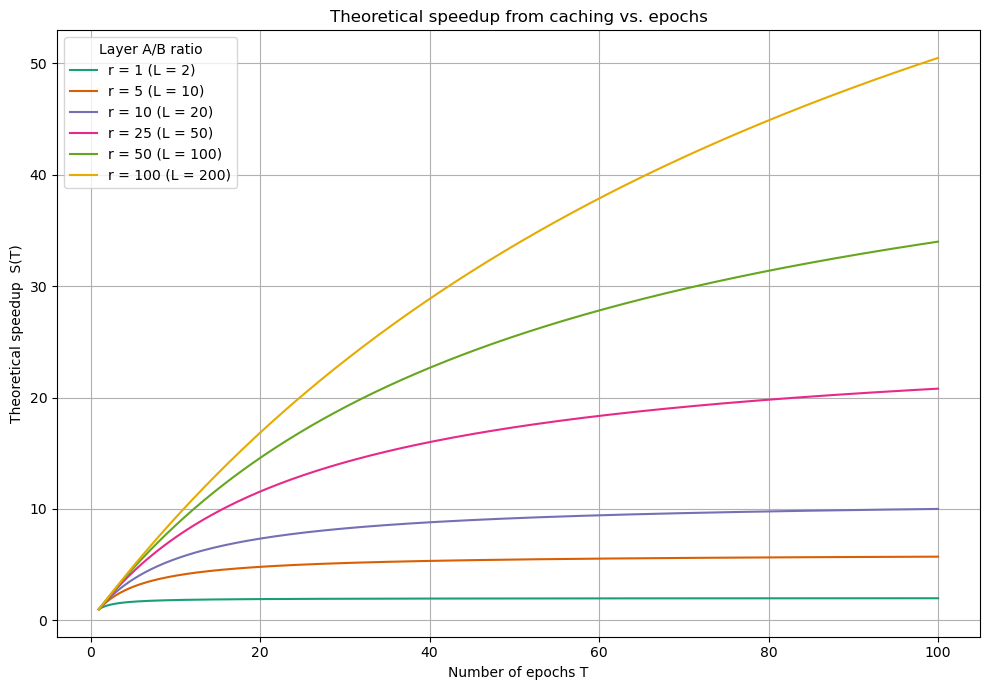

In [2]:
# ratio r = A/B = L/2  (how many times heavier the cached part is)
r_values = [1, 5, 10, 25, 50, 100]
T = np.linspace(1, 100, 500)  # epochs range

def theoretical_speedup(ratio, epochs):
    return epochs * (1 + ratio) / (epochs + ratio)

fig, ax = plt.subplots(figsize=(10, 7))
colors = list(map(plt.cm.Dark2, range(8)))
for i, r in enumerate(r_values):
    S = theoretical_speedup(r, T)
    # plt.plot(T, S, label=f"r = {r}")
    plt.plot(T, S, label=f"r = {r} (L = {2*r})", c=colors[i])

# plt.axhline(1, c='k', linestyle="--", label="speedup 1")
plt.xlabel("Number of epochs T")
plt.ylabel("Theoretical speedup  S(T)")
plt.title("Theoretical speedup from caching vs. epochs")
plt.legend(title="Layer A/B ratio")
plt.grid(True)
plt.tight_layout()
plt.show()


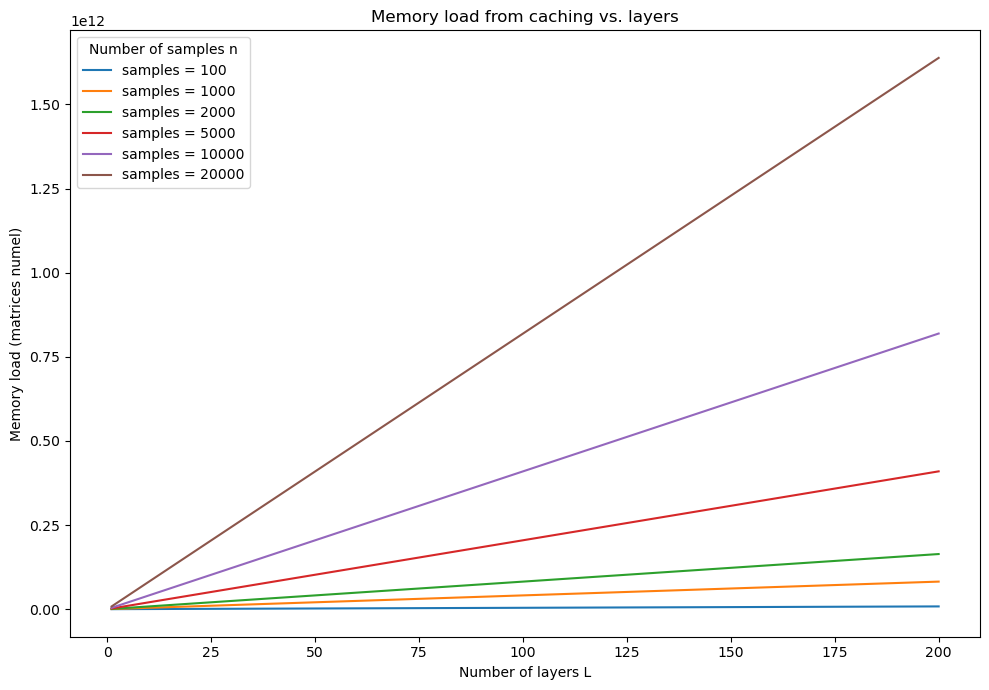

In [3]:
# T = np.linspace(1, 100, 500)  # epochs range
n_values = [100, 1_000, 2_000, 5_000, 10_000, 20_000]
L = np.linspace(1, 200, 500)

def memory_load(L, n=20_000, cin=100, cout=100, width=32, height=32):
    return n * L * 2*(width * height) * (cin + cout)

fig, ax = plt.subplots(figsize=(10, 7))
for i, n in enumerate(n_values):
    M = memory_load(L, n=n)
    plt.plot(L, M, label=f"samples = {n}")


plt.xlabel("Number of layers L")
plt.ylabel("Memory load (matrices numel)")
plt.title("Memory load from caching vs. layers")
plt.legend(title="Number of samples n")
plt.tight_layout()
plt.show()

In [4]:
if "/home/sdouka/Documents/Projects/InriaGitlab/experimental_grow/" not in sys.path:
    sys.path.append("/home/sdouka/Documents/Projects/InriaGitlab/experimental_grow/")

In [117]:
import torch
from tqdm import tqdm
from gromo.utils.utils import evaluate_extended_dataset, evaluate_dataset
from tools.datasets import get_dataset
from tools.utils import global_device
from experiments.auxilliary_functions import line_search
from pipeline import cnn

In [6]:
trainset, valset, testset = get_dataset("cifar10", "../data", split_train_val=0.6)
valsize = int(0.5 * len(valset)) # type: ignore
devset, valset = torch.utils.data.random_split(valset, [valsize, valsize])
print(f"{len(trainset)=}, {len(devset)=}, {len(valset)=}, {len(testset)=}") # type: ignore
print(f"{trainset.dataset.data.shape=}") # type: ignore
in_channels = trainset.dataset.data.shape[-1] # type: ignore
out_features = len(np.unique(trainset.dataset.targets)) # type: ignore
input_shape = trainset.dataset.data.shape[1:-1] # type: ignore
print(f"{in_channels=} {out_features=} {input_shape=}")

train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True)
dev_dataloader = torch.utils.data.DataLoader(devset, batch_size=512)
val_dataloader = torch.utils.data.DataLoader(valset, batch_size=1024)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=1024)

len(trainset)=20000, len(devset)=15000, len(valset)=15000, len(testset)=10000
trainset.dataset.data.shape=(50000, 32, 32, 3)
in_channels=3 out_features=10 input_shape=(32, 32)


/home/sdouka/Documents/Projects/InriaGitlab/experimental_grow/tools/datasets.py:488: UserWarning: split_train_val=0.6 is greater than 0.5 this means that the validation set is greater than the training set
  warn(


In [7]:
loss_fn = torch.nn.CrossEntropyLoss()
model = cnn.CNN(
    input_shape=input_shape,
    in_channels=in_channels,
    out_channels=10,
    out_features=out_features,
    neurons=100,
    neuron_epochs=100,
    neuron_lrate=1e-3,
    neuron_batch_size=128,
    loss_fn=loss_fn,
    device=global_device(),
)
model

CNN(
  (growing_dag): GrowingGraphNetwork(
    (loss_fn): CrossEntropyLoss()
    (dag): GrowingDAG[dag1](
    	Nodes (2):
    		start@dag1 (layer type: convolution, hidden size: 3)
    		end@dag1 (layer type: convolution, hidden size: 10)
    	Edges (1):
    		start@dag1->end@dag1
    )
  )
  (linear_merge): LinearMergeGrowingModule module with 1 previous modules and 1 next modules.
  (mlp1): LinearGrowingModule(LinearGrowingModule(mlp1))(in_features=10240, out_features=50, use_bias=True)
  (mlp2): Linear(in_features=50, out_features=10, bias=True)
)

In [119]:
or_val_acc, or_val_loss = evaluate_dataset(model, val_dataloader, loss_fn)
or_val_acc, or_val_loss

(0.09173333333333333, 2.3388425985972088)

In [8]:
generations = model.growing_dag.dag.define_next_actions()

In [9]:
model.init_computation()

# Initialize activities
pre_activities_grad = {
    node: torch.empty(0) for node in model.growing_dag.dag.nodes if node!=model.growing_dag.dag.root
}
input_B = {node: torch.empty(0) for node in model.growing_dag.dag.nodes}
bottleneck = {}

# Forward - backward loop
for X, Y in tqdm(train_dataloader):
    X, Y = X.to(model.device), Y.to(model.device)
    model.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, Y) # TODO: check loss reduction
    loss.backward()
    # Update tensors
    model.update_computation()

    # Accumulate pre-activity gradients and input tensors on cpu
    for node_module in model.growing_dag.dag.get_all_node_modules():
        assert node_module.activity is not None
        # Save input activity of input layers
        input_B[node_module._name] = torch.cat(
            (
                input_B[node_module._name],
                node_module.activity.clone().detach().cpu(),
            )
        )
        if node_module._name == model.growing_dag.dag.root:
            continue
        assert node_module.pre_activity is not None
        assert node_module.pre_activity.grad is not None
        # Save pre activiy gradients
        pre_activities_grad[node_module._name] = torch.cat(
            (
                pre_activities_grad[node_module._name],
                node_module.pre_activity.grad.clone().detach().cpu(),
            )
        )

# Compute optimal updates
model.compute_optimal_delta()

# Retrieve expressivity bottleneck and inputs on important nodes
with torch.no_grad():
    for node_module in model.growing_dag.dag.get_all_node_modules():
        if node_module._name == model.growing_dag.dag.root:
            continue
        # Compute expressivity bottleneck
        v_proj = pre_activities_grad[node_module._name]
        for module in node_module.previous_modules:
            v_proj -= (
                module.optimal_delta_layer(
                    input_B[module.previous_module._name].to(module.device)
                ).cpu()
            )

        bottleneck[node_module._name] = v_proj

del pre_activities_grad
model.reset_computation()

100%|██████████| 40/40 [00:11<00:00,  3.61it/s]


In [10]:
print("Input_B:")
for node, mat in input_B.items():
    bsize =  mat.element_size() * mat.nelement()
    print(f"  {node=} {mat.shape} {bsize*1e-6}MB {bsize*1e-9}GB")
print("Bottleneck:")
for node, mat in bottleneck.items():
    bsize =  mat.element_size() * mat.nelement()
    print(f"  {node=} {mat.shape} {bsize*1e-6}MB {bsize*1e-9}GB")

Input_B:
  node='start@dag1' torch.Size([20000, 3, 32, 32]) 245.76MB 0.24576GB
  node='end@dag1' torch.Size([20000, 10, 32, 32]) 819.1999999999999MB 0.8192GB
Bottleneck:
  node='end@dag1' torch.Size([20000, 10, 32, 32]) 819.1999999999999MB 0.8192GB


In [11]:
sample_sizes = [10, 100, 1_000, 2_000, 5_000, 10_000, 20_000]

expansion = generations[0]
expansion

[Expansion]: New node 1_a from start@dag1 to end@dag1

In [12]:
import gc
gc.collect()

60

In [13]:
model.currently_updated_layer_index = 0

In [16]:
loss_history = {}
dev_res, val_res = {}, {}

In [17]:
for samples in tqdm(sample_sizes):
    samples = min(samples, len(trainset))
    expansion.expand()

    # Update weights of new edges
    bott_loss_history = model.growing_dag.expand_node(
        expansion=expansion,
        bottlenecks={k: v[:samples] for k, v in bottleneck.items()},
        activities={k: v[:samples] for k, v in input_B.items()},
        verbose=True,
    )
    loss_history[samples] = bott_loss_history
    mask = expansion.create_mask()
    (
        factor,
        dev_loss,
        dev_acc,
        _,
        _,
        _,
    ) = line_search(
        model=model,
        dataloader=dev_dataloader,
        loss_function=torch.nn.CrossEntropyLoss(reduction="sum"),
        mask=mask,
        device=model.device,
    )
    model.set_scaling_factor(factor)
    dev_res[samples] = (dev_acc, dev_loss)
    val_res[samples] = evaluate_extended_dataset(model, val_dataloader, loss_fn, mask=mask)
    model.set_scaling_factor(1)

  0%|          | 0/7 [00:00<?, ?it/s]/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Epoch 0: Train loss 1.2956523895263672
Epoch 10: Train loss 0.016544723883271217
Epoch 20: Train loss 0.022199369966983795
Epoch 30: Train loss 0.012129876762628555
Epoch 40: Train loss 0.0009991618571802974
Epoch 50: Train loss 0.0010652594501152635
Epoch 60: Train loss 0.000521888374350965
Epoch 70: Train loss 0.00025754832313396037
Epoch 80: Train loss 9.563004277879372e-05
Epoch 90: Train loss 7.537046622019261e-05


/home/sdouka/Documents/Projects/InriaGitlab/experimental_grow/experiments/auxilliary_functions.py:457: UserWarning: Initial loss is not provided, computing it
  warn("Initial loss is not provided, computing it")


Initial loss: 2.342e+00


 14%|█▍        | 1/7 [01:08<06:53, 68.90s/it]

...

 71%|███████▏  | 5/7 [06:19<02:41, 80.69s/it]

Epoch 0: Train loss 0.04468497318931107
Epoch 10: Train loss 2.8080221080570114e-06
Epoch 20: Train loss 1.0532370273595698e-06
Epoch 30: Train loss 4.58895967436616e-07
Epoch 40: Train loss 2.2581390156355603e-07
Epoch 50: Train loss 1.2216382563211264e-07
Epoch 60: Train loss 7.000918753298801e-08
Epoch 70: Train loss 4.274640788735326e-08
Epoch 80: Train loss 2.788317429549294e-08
Epoch 90: Train loss 1.8551481689791696e-08
Initial loss: 2.342e+00


 86%|████████▌ | 6/7 [08:24<01:35, 95.71s/it]

Epoch 0: Train loss 0.022530380876027278
Epoch 10: Train loss 8.677038883700328e-07
Epoch 20: Train loss 1.9506939164890575e-07
Epoch 30: Train loss 6.540617941661778e-08
Epoch 40: Train loss 2.857827095989138e-08
Epoch 50: Train loss 1.2300462355680756e-08
Epoch 60: Train loss 1.4209677707948842e-07
Epoch 70: Train loss 1.3206978240472917e-07
Epoch 80: Train loss 2.528698269107305e-08
Epoch 90: Train loss 1.4643574384923165e-08
Initial loss: 2.342e+00


100%|██████████| 7/7 [11:26<00:00, 98.01s/it] 


In [18]:
loss_history.keys()

dict_keys([10, 100, 1000, 2000, 5000, 10000, 20000])

In [31]:
val_res

{10: (0.09173333333333333, 2.3388425985972088),
 100: (0.09153333333333333, 2.3387978235880533),
 1000: (0.08866666666666667, 2.3382235844930013),
 2000: (0.0886, 2.3381396929423013),
 5000: (0.0878, 2.3386693477630613),
 10000: (0.0888, 2.3383880456288657),
 20000: (0.0916, 2.3388312339782713)}

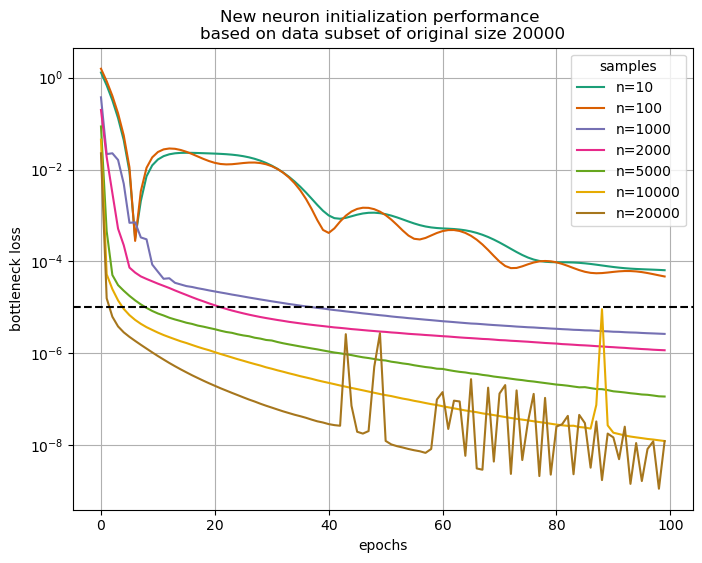

In [116]:
epochs = np.arange(100)

colors = list(map(plt.cm.Dark2, range(8)))
plt.figure(figsize=(8, 6))
i = 0
for samples, loss in loss_history.items():
    plt.plot(epochs, loss, label=f"n={samples}", c=colors[i])
    i+=1

plt.axhline(1e-5, linestyle="--", c="k")
plt.grid()
plt.xlabel("epochs")
plt.ylabel("bottleneck loss")
plt.yscale('log')
plt.legend(title="samples")
plt.title(f"New neuron initialization performance \nbased on data subset of original size {len(trainset)}")
plt.show()

0.09173333333333333
0.09153333333333333
0.08866666666666667
0.0886
0.0878
0.0888
0.0916


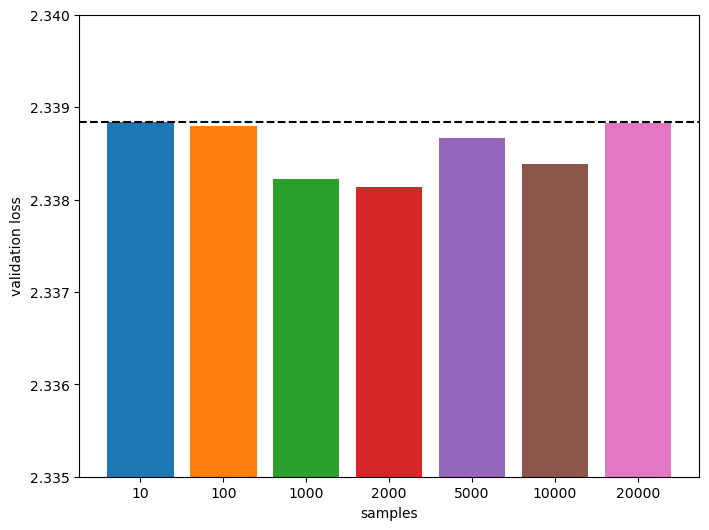

In [128]:
plt.figure(figsize=(8, 6))
i = 0
for samples, loss in loss_history.items():
    print(val_res[samples][0])
    plt.bar(x=i, height=val_res[samples][1], label=samples)
    i+=1

plt.axhline(or_val_loss, linestyle="--", c="k")
plt.xlabel("samples")
plt.ylabel("validation loss")
plt.ylim([2.335, 2.34])
plt.xticks(np.arange(i), sample_sizes)
plt.show()